# Bonus — Browser Testing with Playwright (Python)

**Bonus Module · AI Testing course**

---

Modules 1–9 tested *models and agents*. But most software users touch through a **browser**, and testing that means driving a real browser: click, type, navigate, and assert what the user actually sees. **Playwright** is the modern tool for exactly that — automation *and* end-to-end (E2E) testing.

## What we'll do (all live, in a real browser)
1. Launch a browser and read a page
2. Take a screenshot and view it here
3. Find elements with **locators** and extract data
4. **Interact** (type, click) and use **web-first assertions** on the official TodoMVC demo
5. See why Playwright's **auto-waiting** makes tests reliable, not flaky

Then two files show the real-world shape: a **`pytest` E2E test** and a **headed "watch it live" script**.

> **Runs in its own isolated `.venv`.** Setup: `pip install -r requirements.txt` then `playwright install chromium`. This notebook uses Playwright's **async** API (which works inside Jupyter's event loop); the `.py` files use the simpler **sync** API.

## What is Playwright — and why it's good for *testing*

Playwright drives Chromium, Firefox, and WebKit from one API. Three things make it a *testing* tool, not just a scraper:

- **Auto-waiting** — before any action it waits for the element to be visible, enabled, and stable. No more `sleep(2)` guesswork — the #1 cause of flaky UI tests.
- **Locators** — durable, meaning-based element handles (`get_by_role`, `get_by_text`, `get_by_test_id`) that survive layout changes, instead of brittle CSS/XPath.
- **Web-first assertions** — `expect(locator).to_have_text(...)` **auto-retries** until it passes or times out, so tests aren't racing the page.

That's the same testing mindset from this course: assert on *what the user experiences*, and make the check robust to noise.

## 1. Launch a browser

We start Playwright and open one page, and **keep them alive across cells** so each demo builds on the last. (Headless = no visible window; the `.py` scripts show a headed, watchable version.)

In [2]:
pip install playwright

  Using cached playwright-1.61.0-py3-none-macosx_11_0_arm64.whl.metadata (3.3 kB)
  Using cached pyee-13.0.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached greenlet-3.5.4-cp314-cp314-macosx_11_0_universal2.whl.metadata (3.8 kB)
Using cached playwright-1.61.0-py3-none-macosx_11_0_arm64.whl (42.2 MB)
Using cached greenlet-3.5.4-cp314-cp314-macosx_11_0_universal2.whl (295 kB)
Using cached pyee-13.0.1-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [playwright]3 [playwright]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from playwright.async_api import async_playwright, expect

pw = await async_playwright().start()
browser = await pw.chromium.launch(headless=True)
page = await browser.new_page()
print("browser launched, blank page ready")

browser launched, blank page ready


## 2. Navigate and read a page

`goto` loads a URL; `title()` and locators read what's there.

In [ ]:
await page.goto("https://example.com", timeout=20000)
print("URL   :", page.url)
print("Title :", await page.title())
print("H1    :", await page.locator("h1").inner_text())

URL   : https://example.com/
Title : Example Domain
H1    : Example Domain


## 3. Take a screenshot and view it

A screenshot is the fastest way to *see* what the automated browser sees — great for debugging a failing test.

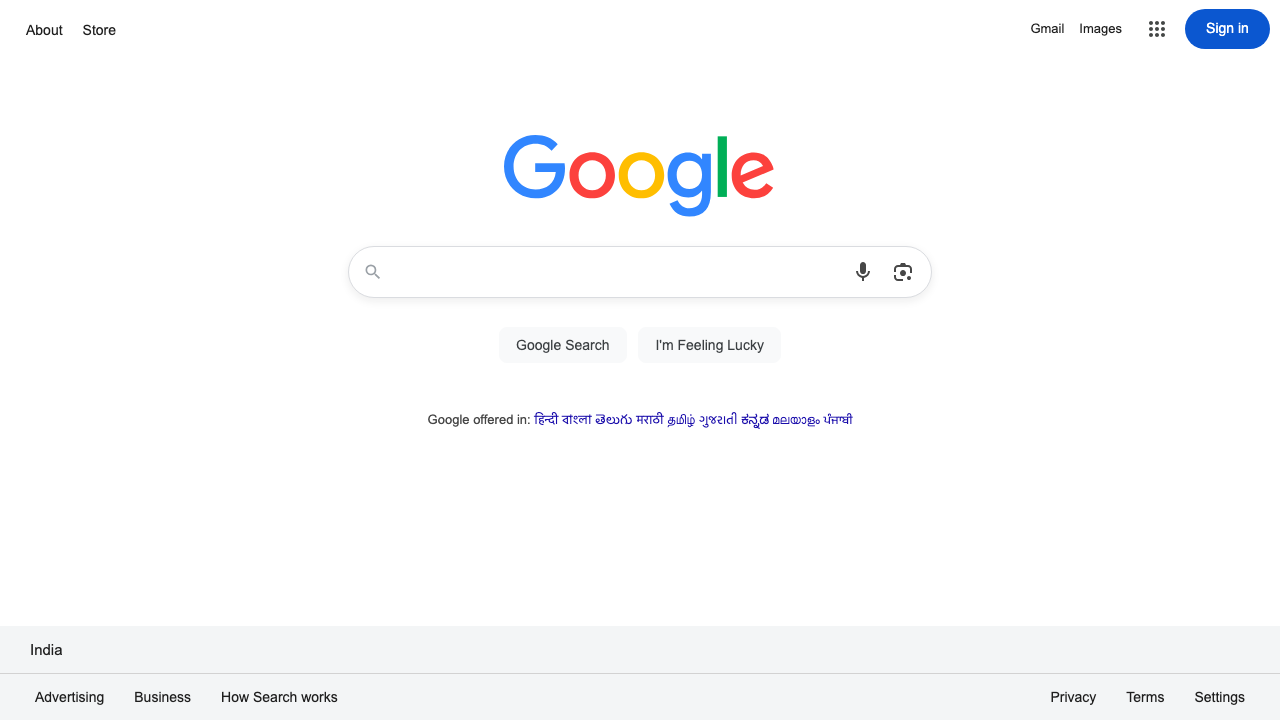

In [6]:
await page.goto("https://google.com", timeout=20000)
await page.screenshot(path="screenshot.png")

from IPython.display import Image
Image("screenshot.png", width=680)

## 4. Locators — find elements by meaning, and extract data

Instead of fragile CSS paths, address elements the way a *user* thinks about them. Here we read the page's main heading and count its links.

In [ ]:
# The big hero heading, by its role
heading = page.get_by_role("heading", level=1)
print("Hero heading:", await heading.inner_text())

# Count all links on the page
links = page.get_by_role("link")
print("Number of links on playwright.dev:", await links.count())

# Pull the text of the first few nav links
nav_texts = await page.get_by_role("link").all_inner_texts()
print("First 6 link texts:", [t for t in nav_texts if t][:6])

## 5. Interact + assert — the official TodoMVC demo

Now the heart of E2E testing: **do what a user does** (type a todo, press Enter) and **assert the result**. `demo.playwright.dev/todomvc` is Playwright's own practice app.

Watch the assertions: `expect(...).to_have_count(2)` **auto-retries** until the DOM matches — you never wrote a single `sleep`.

In [ ]:
await page.goto("https://demo.playwright.dev/todomvc", timeout=20000)

new_todo = page.get_by_placeholder("What needs to be done?")
for task in ["Write a Playwright test", "Watch it auto-wait", "Ship with confidence"]:
    await new_todo.fill(task)
    await new_todo.press("Enter")

todos = page.get_by_test_id("todo-title")
await expect(todos).to_have_count(3)          # web-first assertion: auto-retries
print("todos on screen:", await todos.count())
print("texts:", await todos.all_inner_texts())

In [ ]:
# Complete the FIRST todo by ticking its own checkbox.
# (Gotcha: get_by_role('checkbox').first would grab TodoMVC's hidden
#  'toggle-all' checkbox and complete everything — so we scope to the
#  first list item, then its checkbox.)
await page.locator(".todo-list li").first.get_by_role("checkbox").check()

# The footer shows "N items left" — assert it dropped to 2
await expect(page.get_by_test_id("todo-count")).to_contain_text("2")
print("remaining:", await page.get_by_test_id("todo-count").inner_text())

# A quick screenshot of the final state
await page.screenshot(path="todos.png")
from IPython.display import Image
Image("todos.png", width=520)

## 6. Why this doesn't flake

Notice what we *didn't* write: no `time.sleep`, no manual "wait for element" loops. Every action auto-waited for the element to be ready, and every `expect(...)` retried until the page caught up. That is the difference between a UI test you can trust in CI and one that fails randomly at 2am.

- **Action** (`fill`, `press`, `check`) → waits for the element to be actionable.
- **Assertion** (`expect(...).to_...`) → retries for a few seconds before failing.

Same principle as the rest of this course: make the check robust to the system's non-determinism.

## Clean up

Close the browser and stop Playwright.

In [ ]:
await browser.close()
await pw.stop()
print("closed")

## From notebook to a real test suite

Notebooks are great for exploring; real E2E tests live in files and run in CI. This folder has two:

- **`test_todomvc.py`** — the same TodoMVC flow as a **`pytest` test** (using `pytest-playwright`, which gives you a ready `page` fixture). Run it:
  ```bash
  pytest                      # headless, like CI
  pytest --headed --slowmo 500   # watch it happen
  ```
- **`demo_headed.py`** — a standalone script that opens a **visible** browser and walks the flow slowly, so you can literally watch Playwright drive it:
  ```bash
  python demo_headed.py
  ```

### Summary
- **Playwright** drives a real browser to test what users actually see.
- **Locators** (by role/text/test-id) + **auto-waiting** + **web-first assertions** = reliable UI tests, not flaky ones.
- You explored it live here; `test_todomvc.py` shows the production shape (pytest + CI), and `demo_headed.py` lets you watch it run.

Same testing mindset as the whole course — assert on real user-facing behaviour, and make the assertion robust to timing.